In [2]:
import os
if 'PATH_SET' not in locals():
    os.chdir('..')
    PATH_SET = True
    
import torch    


import numpy as np

import pandas as pd
import xarray as xr
import shapely

import tqdm as tqdm

import matplotlib.pyplot as plt
import matplotlib.style as style
style.use('https://raw.githubusercontent.com/dominik-strutz/dotfiles/main/mystyle.mplstyle')

figure_path = 'figures/priors/'
os.makedirs(figure_path, exist_ok=True)

from helpers.transparent_colormaps import red_cmap, blue_cmap

In [3]:
from helpers.helper_functions import (
    concave_hull2D_prior_dist_constructor,
    convex_hull2D_prior_dist_constructor,
)
from helpers.geographic_setup import (
    topo_data, nodes_full, nodes_shoulder, das_full,
    picking_stats_lines, picking_stats_shoulder, grid_coords)

In [4]:
concave_hull2D_prior = concave_hull2D_prior_dist_constructor(
    nodes_full[['easting', 'northing']].values,
    topo_data,
    buffer=50,
    depth=0,
    ratio=0.05,
    base_dist='sobol'
)

In [5]:
convex_hull2D_shoulder = convex_hull2D_prior_dist_constructor(
    nodes_shoulder[['easting', 'northing']].values[:379],
    topo_data,
    buffer=20,
    depth=0,
    base_dist='sobol'
)

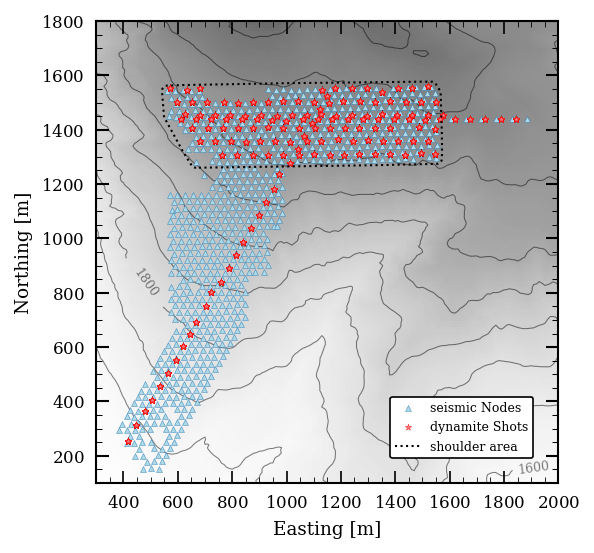

In [7]:
fig, ax = plt.subplots(1, 1, figsize=(4, 4))


ax.pcolormesh(
topo_data.easting, topo_data.northing, topo_data.values.T, rasterized=True,
cmap='Greys', zorder=-20, alpha=0.8)

ax.pc = ax.contour(
    topo_data.easting, topo_data.northing, topo_data.values.T, 
    colors='k', zorder=-10,
    levels=np.arange(0, 3000, 100),
    linewidths=0.5, alpha=0.5)

ax.cl = ax.clabel(
    ax.pc,
    levels=np.arange(0, 3000, 200),
    inline=True, fontsize=6, fmt='%1.0f', colors='k', use_clabeltext=True)

# ax.plot(
#     *np.array(concave_hull2D_prior.shapley_poly.exterior.coords.xy),
#     color='k', linewidth=1.0, linestyle='--', zorder=2, alpha=1.0, 
#     label='accesible area')

# Seismic nodes
ax.scatter(
    nodes_full['easting'], nodes_full['northing'],
    c='lightblue', s=8, linewidths=0.2,
    edgecolor='tab:blue',
    zorder=5,
    marker='^',
    label='seismic Nodes')

# DAS cables
# ax.plot(
#     das_full['easting'][:3178], das_full['northing'][:3178],
#     color='yellow', linewidth=1.5, linestyle='-', zorder=6,
#     label='DAS cables'
# )
# ax.plot(
#     das_full['easting'][3178:], das_full['northing'][3178:],
#     color='yellow', linewidth=1.5, linestyle='-', zorder=7,
# )

# Dynamite shots
ax.scatter(
    picking_stats_shoulder['src_easting'], picking_stats_shoulder['src_northing'],
    c='lightcoral', s=10, marker='*', zorder=6, linewidth=0.2,
    edgecolor='red',
    label='dynamite Shots',
)
ax.scatter(
    picking_stats_lines['src_easting'], picking_stats_lines['src_northing'],
    c='lightcoral', s=10, marker='*', zorder=6, linewidth=0.2,
    edgecolor='red',
)

ax.plot(
    convex_hull2D_shoulder.shapley_poly.exterior.coords.xy[0],
    convex_hull2D_shoulder.shapley_poly.exterior.coords.xy[1],
    color='k', linewidth=1.0, linestyle=':', zorder=20, alpha=1.0,
    label='shoulder area')

ax.set_aspect('equal')
ax.set_xlabel('Easting [m]')
ax.set_ylabel('Northing [m]')

ax.set_xlim(300, 2000)
ax.set_ylim(100, 1800)

ax.legend(
    loc='lower right', fontsize=6,
    facecolor='white', edgecolor='black', framealpha=1.0)

fig.savefig(figure_path+'geographic_setup.png', dpi=300)
fig.savefig(figure_path+'geographic_setup.pdf', dpi=300)

plt.show()

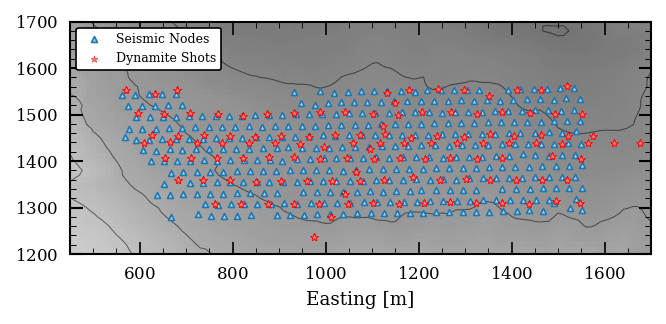

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(5, 5))


ax.pcolormesh(
topo_data.easting, topo_data.northing, topo_data.values.T, rasterized=True,
cmap='Greys', zorder=-20, alpha=0.8)

ax.pc = ax.contour(
    topo_data.easting, topo_data.northing, topo_data.values.T, 
    colors='k', zorder=-10,
    levels=np.arange(0, 3000, 100),
    linewidths=0.5, alpha=0.5)

ax.cl = ax.clabel(
    ax.pc,
    levels=np.arange(0, 3000, 200),
    inline=True, fontsize=6, fmt='%1.0f', colors='k', use_clabeltext=True)

# ax.plot(
#     *np.array(concave_hull2D_prior.shapley_poly.exterior.coords.xy),
#     color='k', linewidth=1.0, linestyle='--', zorder=2, alpha=1.0, 
#     label='accesible area')

# Seismic nodes
ax.scatter(
    nodes_shoulder['easting'], nodes_shoulder['northing'],
    c='lightblue', s=8,
    edgecolor='tab:blue',
    zorder=5,
    marker='^',
    label='Seismic Nodes')

# Dynamite shots
ax.scatter(
    picking_stats_shoulder['src_easting'], picking_stats_shoulder['src_northing'],
    c='lightcoral', s=12, marker='*', zorder=6, linewidth=0.2,
    edgecolor='red',
    label='Dynamite Shots',
)
ax.scatter(
    picking_stats_lines['src_easting'], picking_stats_lines['src_northing'],
    c='lightcoral', s=12, marker='*', zorder=6, linewidth=0.2,
    edgecolor='red',
)

ax.set_aspect('equal')
ax.set_xlabel('Easting [m]')

ax.set_xlim(300, 2100)
ax.set_ylim(100, 1900)

ax.legend(
    loc='upper left', fontsize=6, borderaxespad=0.5,
    facecolor='white', edgecolor='black', framealpha=1.0)

ax.set_xlim(450, 1700)
ax.set_ylim(1200, 1700)

fig.savefig(figure_path+'geographic_setup_shoulder.png', dpi=300)
fig.savefig(figure_path+'geographic_setup_shoulder.pdf', dpi=300)

plt.show()

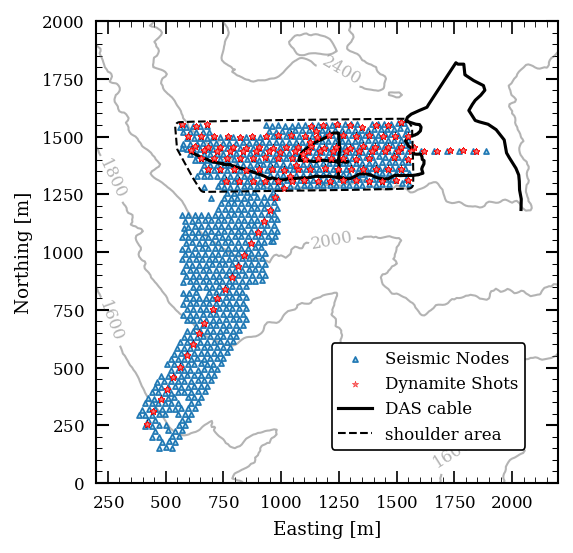

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(4, 4))

# ax.pcolormesh(
#     topo_data.easting, topo_data.northing, topo_data.values.T, rasterized=True,
#     cmap='Greys', zorder=-20, alpha=0.8)

# ax.pc = ax.contour(
#     topo_data.easting, topo_data.northing, topo_data.values.T, 
#     colors='k', zorder=-10,
#     levels=np.arange(0, 3000, 100),
#     linewidths=0.5, alpha=0.5)

# ax.cl = ax.clabel(
#     ax.pc,
#     levels=np.arange(0, 3000, 100),
#     inline=True, fontsize=6, fmt='%1.0f', colors='k', use_clabeltext=True)

topo_data_clipped = topo_data.sel(
    easting=slice(200, 2200),
    northing=slice(0, 2000)
)

contour = ax.contour(
    topo_data_clipped.easting, topo_data_clipped.northing, topo_data_clipped.values.T, 
    colors='dimgray', alpha=0.5,
    levels=[1600, 1800, 2000, 2200, 2400, 2600, 2800],
    linewidths=1.0)
ax.clabel(contour, inline=True, fontsize=8, fmt='%1.0f')

# ax.plot(
#     *np.array(concave_hull2D_prior.shapley_poly.exterior.coords.xy),
#     color='k', linewidth=1.0, linestyle='--', zorder=2, alpha=1.0, 
#     label='accesible area')

# Seismic nodes
ax.scatter(
    nodes_full['easting'], nodes_full['northing'],
    c='lightblue', s=6,
    edgecolor='tab:blue',
    zorder=5,
    marker='^',
    label='Seismic Nodes')


# Dynamite shots
ax.scatter(
    picking_stats_shoulder['src_easting'], picking_stats_shoulder['src_northing'],
    c='lightcoral', s=10, marker='*', zorder=6, linewidth=0.2,
    edgecolor='red',
    label='Dynamite Shots',
)
ax.scatter(
    picking_stats_lines['src_easting'], picking_stats_lines['src_northing'],
    c='lightcoral', s=10, marker='*', zorder=6, linewidth=0.2,
    edgecolor='red',
)

# DAS cables
ax.plot(
    das_full['easting'][:3178], das_full['northing'][:3178],
    color='k', linewidth=1.5, linestyle='-', zorder=5,
    label='DAS cable'
)
ax.plot(
    das_full['easting'][3178:], das_full['northing'][3178:],
    color='k', linewidth=1.5, linestyle='-', zorder=5,
)

ax.plot(
    convex_hull2D_shoulder.shapley_poly.exterior.coords.xy[0],
    convex_hull2D_shoulder.shapley_poly.exterior.coords.xy[1],
    color='k', linewidth=1.0, linestyle='--', zorder=20, alpha=1.0,
    label='shoulder area')

ax.set_aspect('equal')
ax.set_xlabel('Easting [m]')
ax.set_ylabel('Northing [m]')

ax.set_xlim(200, 2200)
ax.set_ylim(0, 2000)

ax.legend(
    loc='lower right', fontsize=8,
    facecolor='white', edgecolor='black', framealpha=1.0)

fig.savefig(figure_path+'geographic_combined.png', dpi=300)
fig.savefig(figure_path+'geographic_combined.pdf', dpi=300)

plt.show()